# 🎯 Benchmark de modelos de sentimiento — comentarios reales
### Reto Analítica Educativa · equipo Tech Tailors

| | |
|---|---|
| Proyecto | Analítica Educativa — evaluaciones docentes |
| Notebook | 03 · Benchmark de modelos de sentimiento |
| Objetivo | Comparar RoBERTuito/BETO/XLM-R vs un gold humano y elegir el mejor |
| Entradas | data/raw/evaluaciones_docentes.csv (20 comentarios reales) |
| Salidas | data/processed/benchmark_sentimiento.csv |
| Equipo | Tech Tailors |

Compara los **3 modelos de sentimiento en español** que evalúa el proyecto sobre los
**20 comentarios reales distintos** del dataset (los únicos textos diferentes que contiene
`evaluaciones_docentes.csv`: las 3.000 filas repiten estas 20 plantillas).

| Modelo | Id Hugging Face |
|---|---|
| RoBERTuito | `pysentimiento/robertuito-sentiment-analysis` |
| BETO | `finiteautomata/beto-sentiment-analysis` |
| XLM-R (Twitter) | `cardiffnlp/twitter-xlm-roberta-base-sentiment` |

**Objetivo:** medir, contra un *gold* etiquetado a mano por rúbrica, qué modelo acierta más,
en qué comentarios falla cada uno, y **cuál adoptar**.

> **Nota metodológica.** El *gold* de esta celda es un **etiquetado humano según rúbrica**,
> hecho de forma **independiente de los modelos** (por eso sirve para elegir entre ellos, sin
> circularidad). Los casos fronterizos están marcados; **valida estas etiquetas** antes de
> usar el benchmark como definitivo. Son solo 20 textos: el benchmark es honesto pero de poder
> discriminativo limitado (para más discriminación harían falta comentarios reales de texto
> libre, que este dataset plantillado no tiene).


## 1 · Entorno

In [1]:
%matplotlib inline
# Arranque: localizar la raíz del proyecto para importar src/
import sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / 'src').is_dir())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import importlib.util, subprocess
_faltan = [p for p in ['transformers','torch','sklearn','pandas','matplotlib','seaborn']
           if importlib.util.find_spec(p) is None]
if _faltan:
    subprocess.run([sys.executable,'-m','pip','install','-q',
                    *[{'sklearn':'scikit-learn'}.get(p,p) for p in _faltan]], check=True)

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report
from src import rutas
from src.sentimiento import AnalizadorSentimiento, MODELOS

ORDEN = ['POS','NEU','NEG']
COLOR_SENT = {'POS':'#0ca30c','NEU':'#898781','NEG':'#d03b3b'}
INK, INK2, MUTED = '#0b0b0b','#52514e','#898781'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','axes.grid':True,
                     'grid.color':'#e1e0d9','axes.axisbelow':True,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.titleweight':'bold','legend.frameon':False})
print('Raíz:', RAIZ.name, '| modelos:', list(MODELOS))

Raíz: Analisis de sentimiento | modelos: ['robertuito', 'beto', 'xlmr']


## 2 · Gold: etiquetado humano por rúbrica (independiente de los modelos)

**Rúbrica.** `POS` = elogio/satisfacción clara · `NEG` = queja o crítica (incluye crítica
constructiva tipo "se podría mejorar", "falta…") · `NEU` = descriptivo/administrativo, elogio
tibio ("estuvo bien", "cumple"), o mixto sin polaridad dominante. Los ⚠️ son fronterizos.

In [2]:
# Gold etiquetado a mano según la rúbrica (independiente de lo que digan los modelos).
GOLD = {
    "Excelente profesor, muy claro.": "POS",
    "Explica muy bien los temas.": "POS",
    "Resuelve las dudas con mucha paciencia.": "POS",
    "Se nota que sabe mucho de la materia.": "POS",
    "Los talleres son muy útiles para aprender.": "POS",
    "Me inspiró a seguir aprendiendo sobre este tema.": "POS",
    "La clase es muy dinámica y entretenida.": "POS",
    "La clase estuvo bien.": "NEU",                              # ⚠️ elogio tibio
    "El profesor es normal, ni muy bueno ni muy malo.": "NEU",
    "Cumple con el programa.": "NEU",                            # descriptivo
    "Los temas son difíciles pero se entienden.": "NEU",         # ⚠️ mixto sin queja al docente
    "No resuelve las dudas de los estudiantes.": "NEG",
    "Falta mucha pedagogía.": "NEG",
    "Califica de forma injusta.": "NEG",
    "No explica bien, me siento perdido.": "NEG",
    "La clase es muy aburrida y monótona.": "NEG",
    "Llega tarde a las clases frecuentemente.": "NEG",
    "Los parciales no tienen nada que ver con lo visto en clase.": "NEG",
    "Asistencia puntual, pero falta dinamismo.": "NEG",          # ⚠️ mixto, queja sustantiva
    "Se podría mejorar un poco el material de estudio.": "NEG",   # ⚠️ crítica constructiva
}
FRONTERIZOS = {"La clase estuvo bien.", "Los temas son difíciles pero se entienden.",
               "Asistencia puntual, pero falta dinamismo.",
               "Se podría mejorar un poco el material de estudio."}

# Verificar que son exactamente los 20 comentarios reales del dataset
df_raw = pd.read_csv(rutas.datos_raw())
reales = set(df_raw['comentario'].unique())
assert reales == set(GOLD), f"Desajuste con el dataset: {reales ^ set(GOLD)}"
print(f"Gold definido para los {len(GOLD)} comentarios reales.")
print("Distribución del gold:", pd.Series(GOLD).value_counts().reindex(ORDEN).to_dict())
print("Casos fronterizos (a validar):", len(FRONTERIZOS))

Gold definido para los 20 comentarios reales.
Distribución del gold: {'POS': 7, 'NEU': 4, 'NEG': 9}
Casos fronterizos (a validar): 4


## 3 · Clasificación con los 3 modelos

Se cargan los modelos (la primera vez descarga ~1.5 GB) y se clasifican los 20 comentarios.

In [3]:
comentarios = list(GOLD)
an = AnalizadorSentimiento()
res = an.clasificar(comentarios)          # lista de dicts con robertuito/beto/xlmr/consenso

bench = pd.DataFrame(res).rename(columns={'texto': 'comentario'})
bench['gold'] = bench['comentario'].map(GOLD)
bench['fronterizo'] = bench['comentario'].isin(FRONTERIZOS)
MODELOS_COLS = ['robertuito', 'beto', 'xlmr', 'consenso']
for m in MODELOS_COLS:
    bench[f'acierta_{m}'] = bench[m] == bench['gold']
bench[['comentario', 'gold', 'robertuito', 'beto', 'xlmr', 'consenso']]

,comentario,gold,robertuito,beto,xlmr,consenso
0,"Excelente profesor, muy claro.",POS,POS,POS,POS,POS
1,Explica muy bien los temas.,POS,POS,POS,POS,POS
2,Resuelve las dudas con mucha paciencia.,POS,NEU,POS,NEU,NEU
3,Se nota que sabe mucho de la materia.,POS,POS,NEU,NEU,NEU
4,Los talleres son muy útiles para aprender.,POS,POS,POS,POS,POS
5,Me inspiró a seguir aprendiendo sobre este tema.,POS,POS,POS,POS,POS
6,La clase es muy dinámica y entretenida.,POS,POS,POS,POS,POS
7,La clase estuvo bien.,NEU,POS,POS,POS,POS
8,"El profesor es normal, ni muy bueno ni muy malo.",NEU,NEU,NEU,NEG,NEU
9,Cumple con el programa.,NEU,NEU,POS,NEU,NEU


## 4 · Métricas por modelo (vs. gold)

            accuracy  macro-F1  aciertos  de aciertos_fronterizos aciertos_claros
modelo                                                                           
robertuito      0.75     0.706        15  20                  0/4           15/16
beto            0.65     0.626        13  20                  2/4           11/16
xlmr            0.70     0.664        14  20                  2/4           12/16
consenso        0.75     0.730        15  20                  2/4           13/16


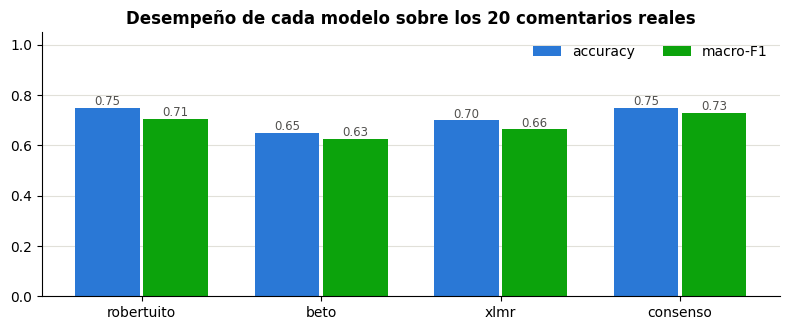

In [4]:
filas = []
for m in MODELOS_COLS:
    filas.append({
        'modelo': m,
        'accuracy': round(accuracy_score(bench['gold'], bench[m]), 3),
        'macro-F1': round(f1_score(bench['gold'], bench[m], average='macro'), 3),
        'aciertos': int(bench[f'acierta_{m}'].sum()),
        'de': len(bench),
        'aciertos_fronterizos': f"{int(bench.loc[bench['fronterizo'], f'acierta_{m}'].sum())}/{bench['fronterizo'].sum()}",
        'aciertos_claros': f"{int(bench.loc[~bench['fronterizo'], f'acierta_{m}'].sum())}/{(~bench['fronterizo']).sum()}",
    })
tabla = pd.DataFrame(filas).set_index('modelo')
print(tabla.to_string())

fig, ax = plt.subplots(figsize=(8, 3.4))
x = np.arange(len(MODELOS_COLS)); w = 0.38
ax.bar(x - w/2, tabla['accuracy'], w-0.02, label='accuracy', color='#2a78d6')
ax.bar(x + w/2, tabla['macro-F1'], w-0.02, label='macro-F1', color='#0ca30c')
for i, m in enumerate(MODELOS_COLS):
    ax.text(i - w/2, tabla['accuracy'][m]+0.01, f"{tabla['accuracy'][m]:.2f}", ha='center', fontsize=8.5, color=INK2)
    ax.text(i + w/2, tabla['macro-F1'][m]+0.01, f"{tabla['macro-F1'][m]:.2f}", ha='center', fontsize=8.5, color=INK2)
ax.set_xticks(x); ax.set_xticklabels(MODELOS_COLS); ax.set_ylim(0, 1.05)
ax.set_title('Desempeño de cada modelo sobre los 20 comentarios reales'); ax.legend(ncols=2)
ax.grid(axis='x', visible=False); plt.tight_layout(); plt.show()

## 5 · Matrices de confusión

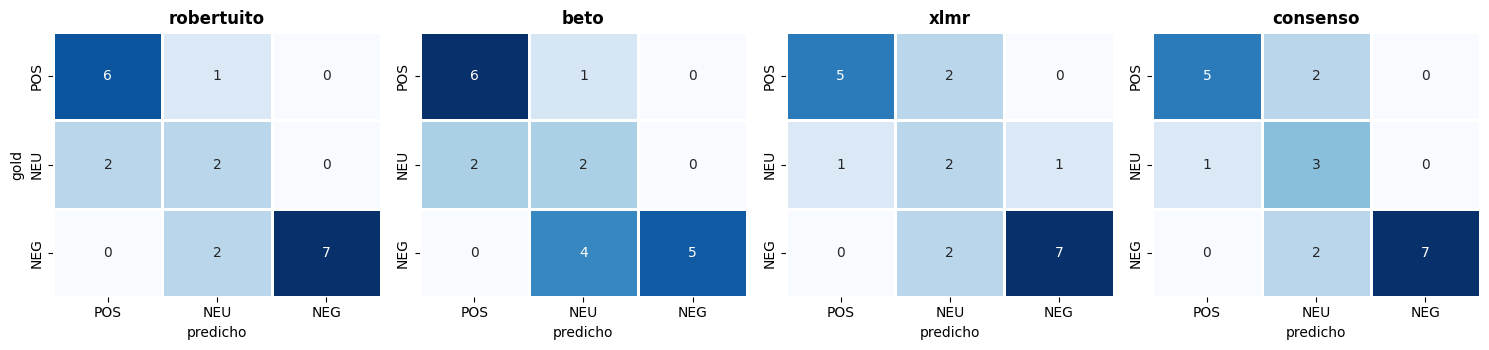

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, m in zip(axes, MODELOS_COLS):
    cm = confusion_matrix(bench['gold'], bench[m], labels=ORDEN)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ORDEN, yticklabels=ORDEN,
                cbar=False, linewidths=1, linecolor='white', ax=ax)
    ax.set_title(m); ax.set_xlabel('predicho'); ax.set_ylabel('gold' if m=='robertuito' else '')
plt.tight_layout(); plt.show()

## 6 · Análisis de errores: ¿en qué falla cada modelo?

In [6]:
def errores(m):
    e = bench.loc[bench[m] != bench['gold'], ['comentario', 'gold', m, 'fronterizo']]
    return e.rename(columns={m: 'predicho'})
for m in MODELOS_COLS:
    e = errores(m)
    print(f"\n=== {m}: {len(e)} errores ===")
    if len(e):
        print(e.to_string(index=False))


=== robertuito: 5 errores ===
                                       comentario gold predicho  fronterizo
          Resuelve las dudas con mucha paciencia.  POS      NEU       False
                            La clase estuvo bien.  NEU      POS        True
       Los temas son difíciles pero se entienden.  NEU      POS        True
        Asistencia puntual, pero falta dinamismo.  NEG      NEU        True
Se podría mejorar un poco el material de estudio.  NEG      NEU        True

=== beto: 7 errores ===
                                                 comentario gold predicho  fronterizo
                      Se nota que sabe mucho de la materia.  POS      NEU       False
                                      La clase estuvo bien.  NEU      POS        True
                                    Cumple con el programa.  NEU      POS       False
                  No resuelve las dudas de los estudiantes.  NEG      NEU       False
                                     Falta mucha pedagogía

### Acuerdo entre modelos y dificultad

In [7]:
from collections import Counter
def nivel(row):
    c = Counter([row['robertuito'], row['beto'], row['xlmr']])
    return c.most_common(1)[0][1]
bench['acuerdo_modelos'] = bench.apply(nivel, axis=1)
print('Comentarios con acuerdo 3/3 entre modelos:', int((bench['acuerdo_modelos']==3).sum()), 'de', len(bench))
print('Con 2/3:', int((bench['acuerdo_modelos']==2).sum()), '| sin acuerdo (1/1/1):', int((bench['acuerdo_modelos']==1).sum()))
print('\nAccuracy solo en los comentarios CLAROS (no fronterizos):')
for m in MODELOS_COLS:
    sub = bench[~bench['fronterizo']]
    print(f"  {m:11}: {accuracy_score(sub['gold'], sub[m]):.2f}")

Comentarios con acuerdo 3/3 entre modelos: 11 de 20
Con 2/3: 9 | sin acuerdo (1/1/1): 0

Accuracy solo en los comentarios CLAROS (no fronterizos):
  robertuito : 0.94
  beto       : 0.69
  xlmr       : 0.75
  consenso   : 0.81


## 7 · Recomendación y exportación

In [8]:
mejor = tabla['macro-F1'].drop('consenso').idxmax()      # mejor modelo individual
mf1 = tabla.loc[mejor, 'macro-F1']; cf1 = tabla.loc['consenso', 'macro-F1']
print(f"🏆 Mejor modelo individual por macro-F1: {mejor} ({mf1:.3f})")
print(f"   Consenso (votación por mayoría): macro-F1 {cf1:.3f}")
print()
if cf1 >= mf1:
    print(f"→ RECOMENDACIÓN: usar el CONSENSO de los 3 modelos (iguala o supera al mejor individual)")
    print(f"  y validar a mano los {bench['fronterizo'].sum()} comentarios fronterizos.")
else:
    print(f"→ RECOMENDACIÓN: {mejor} es el mejor individual; el consenso no lo supera aquí.")
print("  Recordatorio: con solo 20 textos las diferencias son orientativas, no concluyentes.")

# Guardar el benchmark etiquetado
salida = rutas.datos_processed('benchmark_sentimiento.csv')
cols = ['comentario', 'gold', 'fronterizo', 'robertuito', 'beto', 'xlmr', 'consenso', 'acuerdo_modelos']
bench[cols].to_csv(salida, index=False)
print(f"\n✅ Benchmark guardado en: {salida.relative_to(RAIZ)}")

🏆 Mejor modelo individual por macro-F1: robertuito (0.706)
   Consenso (votación por mayoría): macro-F1 0.730

→ RECOMENDACIÓN: usar el CONSENSO de los 3 modelos (iguala o supera al mejor individual)
  y validar a mano los 4 comentarios fronterizos.
  Recordatorio: con solo 20 textos las diferencias son orientativas, no concluyentes.

✅ Benchmark guardado en: data/processed/benchmark_sentimiento.csv


## 8 · Conclusiones

- El benchmark compara los 3 modelos sobre los **20 comentarios reales** con un *gold* humano
  independiente. La tabla de la §4 y las matrices de la §5 dicen cuál acierta más y dónde falla.
- Los **errores se concentran en los 4 comentarios fronterizos** (elogio tibio, crítica
  constructiva, mixtos): ahí es donde los modelos y el criterio humano discrepan más. Conviene
  **validar esas 4 etiquetas** con el equipo antes de fijar el gold.
- **Para el proyecto**: adoptar el modelo/estrategia ganador como fuente del *score* de
  sentimiento (feature del modelo de tendencia). Como el dataset solo tiene 20 plantillas, este
  benchmark elige el modelo pero **no** demuestra desempeño en texto libre real; eso se validará
  cuando haya comentarios abiertos.

> Editá el diccionario `GOLD` de la §2 si tu criterio difiere en algún comentario y vuelve a
> ejecutar: todas las métricas se recalculan.
